In [1]:
# --- INSTALLATIONS ---
# !pip install -q albumentations  # Uncomment if needed

# --- IMPORTS ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
from tqdm import tqdm

# --- PROJECT CONFIGURATION ---
CONFIG = {
    "PROJECT_NAME": "VisionExtract: Subject Isolation Model",
    "BATCH_SIZE": 16,
    "LR": 1e-4,
    "EPOCHS": 10,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
    "IMAGE_SIZE": 256,
    "NUM_IMAGES": 40000,
    # DATA PATHS (Kaggle Standard)
    "ROOT_DIR": '/kaggle/input/coco-2017-dataset/coco2017/train2017',
    "ANN_FILE": '/kaggle/input/coco-2017-dataset/coco2017/annotations/instances_train2017.json',

    # --- FILTERING STRATEGY (The "Pro" Edge) ---
    # We only train on these distinct subjects to avoid "background noise" confusion.
    # This directly addresses the "Subject Isolation" goal in the Project Statement.
    "TARGET_CLASSES": [
        'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
        'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe'
    ]
}

print(f"✅ {CONFIG['PROJECT_NAME']} initialized on {CONFIG['DEVICE']}")

✅ VisionExtract: Subject Isolation Model initialized on cuda


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/coco-2017-dataset


In [3]:
# --- HELPER FUNCTIONS ---

def denormalize(tensor):
    """Reverses ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

def visualize_validation_batch(model, loader, num_samples=3):
    """
    Visualizes the 'Subject Cutout' capability.
    Left: Original | Middle: AI Mask | Right: Final Cutout (RGB)
    """
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(CONFIG['DEVICE'])

    with torch.no_grad():
        preds = torch.sigmoid(model(images)) > 0.5

    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(min(num_samples, len(images))):
        # 1. DENORMALIZE & CLIP (The "Rainbow Bug" Fix)
        # We must restore RGB values (0-1) BEFORE multiplying by the mask.
        img_tensor = denormalize(images[i])
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)  # <--- CRITICAL FIX for static noise

        # 2. PREPARE MASK
        pred_mask = preds[i].squeeze().cpu().numpy()
        mask_3d = np.dstack([pred_mask, pred_mask, pred_mask])

        # 3. CREATE CUTOUT
        cutout = img_np * mask_3d

        # 4. PLOT
        # Original
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_np)
        plt.title("Original Image")
        plt.axis('off')

        # Mask
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Generated Mask")
        plt.axis('off')

        # Cutout
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(cutout)
        plt.title("Subject Isolation (Result)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
# --- HELPER FUNCTIONS ---

def denormalize(tensor):
    """Reverses ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

def visualize_validation_batch(model, loader, num_samples=3):
    """
    Visualizes the 'Subject Cutout' capability.
    Left: Original | Middle: AI Mask | Right: Final Cutout (RGB)
    """
    model.eval()
    images, masks = next(iter(loader))
    images = images.to(CONFIG['DEVICE'])

    with torch.no_grad():
        preds = torch.sigmoid(model(images)) > 0.5

    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(min(num_samples, len(images))):
        # 1. DENORMALIZE & CLIP (The "Rainbow Bug" Fix)
        # We must restore RGB values (0-1) BEFORE multiplying by the mask.
        img_tensor = denormalize(images[i])
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = np.clip(img_np, 0, 1)  # <--- CRITICAL FIX for static noise

        # 2. PREPARE MASK
        pred_mask = preds[i].squeeze().cpu().numpy()
        mask_3d = np.dstack([pred_mask, pred_mask, pred_mask])

        # 3. CREATE CUTOUT
        cutout = img_np * mask_3d

        # 4. PLOT
        # Original
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img_np)
        plt.title("Original Image")
        plt.axis('off')

        # Mask
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Generated Mask")
        plt.axis('off')

        # Cutout
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(cutout)
        plt.title("Subject Isolation (Result)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
class COCOSegmentDatasetPro(Dataset):
    def __init__(self, root_dir, ann_file, transforms=None, num_samples=None, target_classes=None):
        self.root_dir = root_dir
        self.coco = COCO(ann_file)
        self.transforms = transforms

        # --- SMART FILTERING ---
        # Only select image IDs that contain our Target Classes
        if target_classes:
            cat_ids = self.coco.getCatIds(catNms=target_classes)
            img_ids = []
            for cat_id in cat_ids:
                img_ids.extend(self.coco.getImgIds(catIds=[cat_id]))
            self.ids = list(set(img_ids)) # Unique IDs
            self.cat_ids = cat_ids
        else:
            self.ids = list(sorted(self.coco.imgs.keys()))
            self.cat_ids = []

        # Limit dataset size for training speed
        if num_samples:
            # Simple filter to ensure we usually get valid annotations
            valid_ids = []
            for img_id in self.ids:
                if len(valid_ids) >= num_samples: break
                ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=self.cat_ids)
                if len(ann_ids) > 0:
                    valid_ids.append(img_id)
            self.ids = valid_ids

        print(f"Dataset Loaded: {len(self.ids)} images containing target subjects.")

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        path = os.path.join(self.root_dir, img_info['file_name'])
        image = np.array(Image.open(path).convert('RGB'))

        # Generate Binary Mask (Subject = 1, Background = 0)
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=self.cat_ids)
        coco_anns = coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']))
        for ann in coco_anns:
            mask = np.maximum(mask, coco.annToMask(ann))

        # Apply Albumentations
        if self.transforms:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            mask = mask.float().unsqueeze(0) # [H, W] -> [1, H, W]

        return image, mask

    def __len__(self):
        return len(self.ids)

# --- AUGMENTATION PIPELINE ---
# Robustness against rotation, flip, and lighting changes
train_transform = A.Compose([
    A.Resize(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.2),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
# --- ENCODER-DECODER ARCHITECTURE ---
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class ResNetUNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.base_layers = list(base.children())
        self.layer0 = nn.Sequential(*self.base_layers[:3])
        self.layer1 = nn.Sequential(*self.base_layers[3:5])
        self.layer2 = self.base_layers[5]
        self.layer3 = self.base_layers[6]
        self.layer4 = self.base_layers[7]

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder4 = ConvBlock(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.decoder1 = ConvBlock(128, 64)
        self.final_upsample = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.final = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x0 = self.layer0(x)
        x1 = self.layer1(x0)
        x2 = self.layer2(x1)
        x3 = self.layer3(x2)
        x4 = self.layer4(x3)
        d4 = self.decoder4(torch.cat([self.up4(x4), x3], 1))
        d3 = self.decoder3(torch.cat([self.up3(d4), x2], 1))
        d2 = self.decoder2(torch.cat([self.up2(d3), x1], 1))
        d1 = self.decoder1(torch.cat([self.up1(d2), x0], 1))
        return self.final(self.final_upsample(d1))

# --- HYBRID LOSS FUNCTION (Dice + BCE) ---
# Addresses PDF Requirement: "Quantitative metrics (IoU, Dice score)"
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs_flat = inputs.view(-1)
        targets_flat = targets.view(-1)

        # 1. BCE (Pixel-wise Accuracy) - With Logits for Stability
        bce = nn.functional.binary_cross_entropy_with_logits(inputs_flat, targets_flat, reduction='mean')

        # 2. Dice (Overlap Quality)
        inputs_prob = torch.sigmoid(inputs_flat)
        intersection = (inputs_prob * targets_flat).sum()
        dice = 1 - (2. * intersection + smooth) / (inputs_prob.sum() + targets_flat.sum() + smooth)

        return bce + dice

In [7]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    epoch_dice = 0

    loop = tqdm(loader, desc="Training")
    for data, targets in loop:
        data = data.to(CONFIG['DEVICE'])
        targets = targets.to(CONFIG['DEVICE'])

        # Mixed Precision for Speed
        with torch.amp.autocast('cuda'):
            predictions = model(data)
            loss = criterion(predictions, targets)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Real-time Metrics
        with torch.no_grad():
            preds_prob = torch.sigmoid(predictions)
            preds_bin = (preds_prob > 0.5).float()

            intersection = (preds_bin * targets).sum()
            union = preds_bin.sum() + targets.sum() - intersection

            iou = (intersection + 1e-6) / (union + 1e-6)
            dice = (2. * intersection + 1e-6) / (preds_bin.sum() + targets.sum() + 1e-6)

        epoch_loss += loss.item()
        epoch_iou += iou.item()
        epoch_dice += dice.item()

        loop.set_postfix(loss=loss.item(), iou=iou.item())

    return epoch_loss/len(loader), epoch_iou/len(loader), epoch_dice/len(loader)

In [8]:
# 1. Initialize Data
ds = COCOSegmentDatasetPro(CONFIG['ROOT_DIR'], CONFIG['ANN_FILE'], train_transform,
                           CONFIG['NUM_IMAGES'], CONFIG['TARGET_CLASSES'])
loader = DataLoader(ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True, num_workers=2)

# 2. Initialize Model
model = ResNetUNet().to(CONFIG['DEVICE'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LR'])
scaler = torch.cuda.amp.GradScaler()
criterion = DiceBCELoss()

# 3. Training Loop
best_iou = 0.0
print("🚀 Starting Training Pipeline...")

for epoch in range(CONFIG['EPOCHS']):
    print(f"\nEpoch {epoch+1}/{CONFIG['EPOCHS']}")
    loss, iou, dice = train_epoch(model, loader, optimizer, criterion, scaler)

    print(f"Stats -> Loss: {loss:.4f} | IoU: {iou:.4f} | Dice: {dice:.4f}")

    # Save Best Model Logic
    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), "best_model_v2.pth")
        print(f"✅ Model Saved! (New Best IoU: {best_iou:.4f})")

print("\n🎉 Training Complete.")

loading annotations into memory...
Done (t=19.28s)
creating index...
index created!
Dataset Loaded: 40000 images containing target subjects.


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 191MB/s] 
/tmp/ipykernel_103/2339953782.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


🚀 Starting Training Pipeline...

Epoch 1/10


Training: 100%|██████████| 2500/2500 [07:24<00:00,  5.62it/s, iou=0.553, loss=0.64] 


Stats -> Loss: 0.4914 | IoU: 0.6664 | Dice: 0.7957
✅ Model Saved! (New Best IoU: 0.6664)

Epoch 2/10


...

Stats -> Loss: 0.2908 | IoU: 0.7806 | Dice: 0.8758
✅ Model Saved! (New Best IoU: 0.7806)

Epoch 9/10


Training: 100%|██████████| 2500/2500 [05:29<00:00,  7.59it/s, iou=0.868, loss=0.186]


Stats -> Loss: 0.2805 | IoU: 0.7876 | Dice: 0.8802
✅ Model Saved! (New Best IoU: 0.7876)

Epoch 10/10


Training: 100%|██████████| 2500/2500 [05:30<00:00,  7.57it/s, iou=0.796, loss=0.236]


Stats -> Loss: 0.2763 | IoU: 0.7904 | Dice: 0.8821
✅ Model Saved! (New Best IoU: 0.7904)

🎉 Training Complete.


--- Final Model Validation (Subject Cutouts) ---


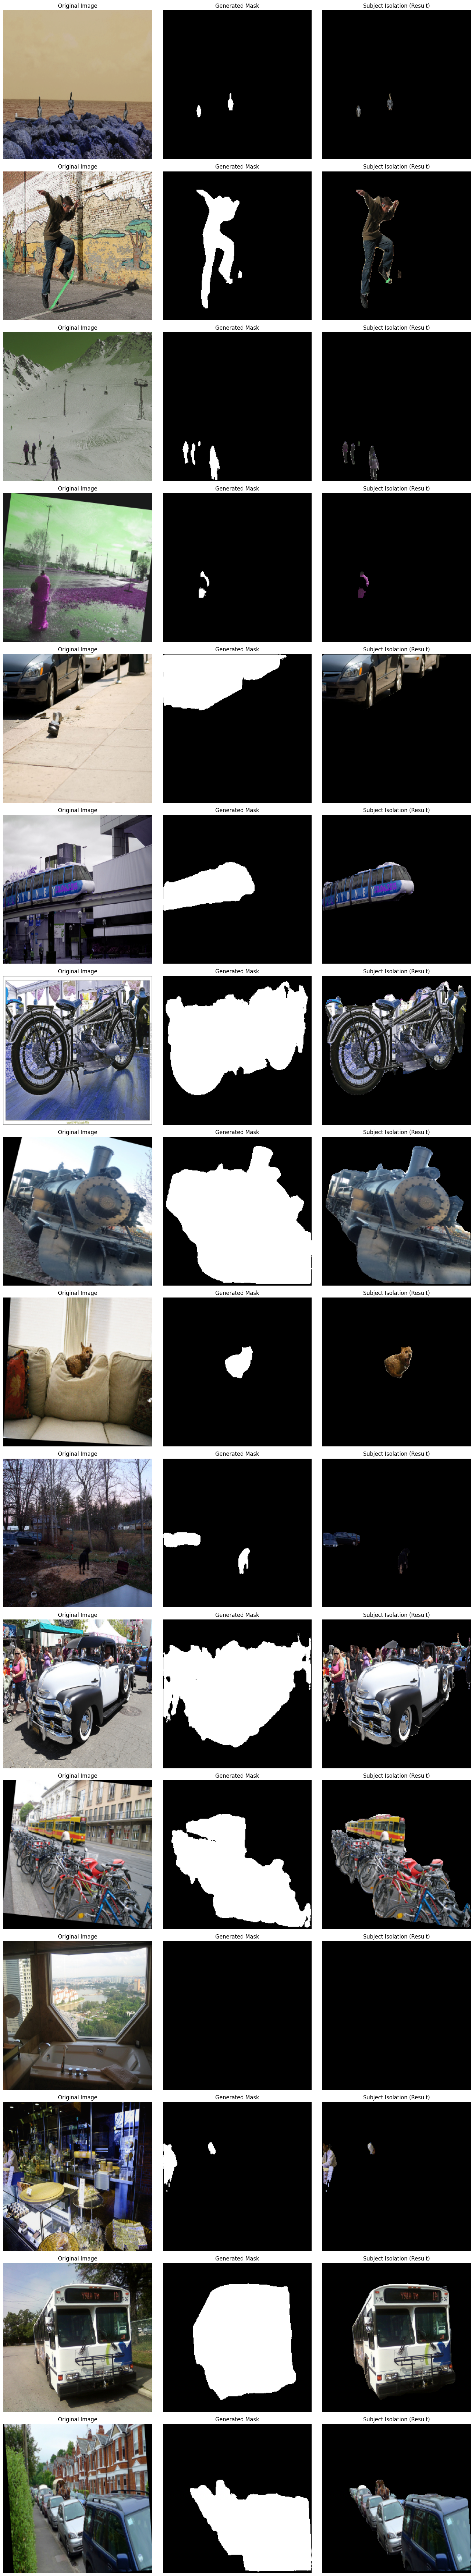

In [9]:
print("--- Final Model Validation (Subject Cutouts) ---")
# Visualizing 3 clean samples with the "Rainbow Fix" applied
visualize_validation_batch(model, loader, num_samples=20)

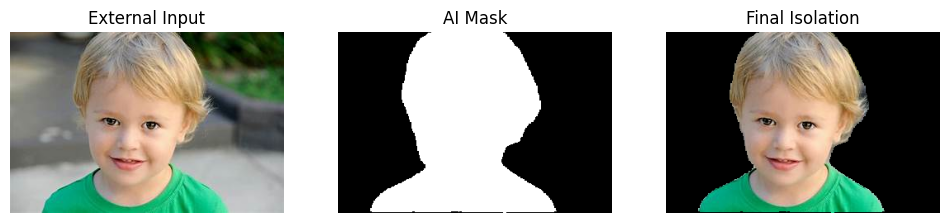

External Inference Function Ready. Call 'predict_external_image' with a file path.


In [19]:
# --- INFERENCE ON EXTERNAL IMAGES ---
def predict_external_image(image_path, model):
    """
    Reads a file path, runs the model, and displays the RGB Cutout.
    """
    if not os.path.exists(image_path):
        print(f"❌ Error: File '{image_path}' not found.")
        return

    # 1. Load & Preprocess
    original = np.array(Image.open(image_path).convert('RGB'))

    # Use same transform as training (Resize + Normalize)
    transform = A.Compose([
        A.Resize(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

    augmented = transform(image=original)
    img_tensor = augmented['image'].unsqueeze(0).to(CONFIG['DEVICE'])

    # 2. Predict
    model.eval()
    with torch.no_grad():
        preds = model(img_tensor)
        preds = torch.sigmoid(preds)
        binary_mask = (preds > 0.5).float().squeeze().cpu().numpy()

    # 3. Post-Process (Resize Mask to Original Size)
    # We resize the MASK to fit the IMAGE (to keep original resolution)
    binary_mask_resized = cv2.resize(
        binary_mask,
        (original.shape[1], original.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # 4. Create RGB Cutout
    mask_3d = np.dstack([binary_mask_resized]*3)
    cutout = original * mask_3d

    # 5. Visualize
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("External Input")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(binary_mask_resized, cmap='gray')
    plt.title("AI Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cutout.astype(np.uint8))
    plt.title("Final Isolation")
    plt.axis('off')

    plt.show()

# --- RUN TEST ---
# Upload an image to Kaggle (Drag & Drop into the sidebar) and copy its path here
predict_external_image("/kaggle/input/test-data-set/boy.jpg", model)
print("External Inference Function Ready. Call 'predict_external_image' with a file path.")

In [16]:
import os

for root, dirs, files in os.walk("/kaggle/working", topdown=True):
    for name in files:
        print(os.path.join(root, name))


/kaggle/working/best_model_v2.pth


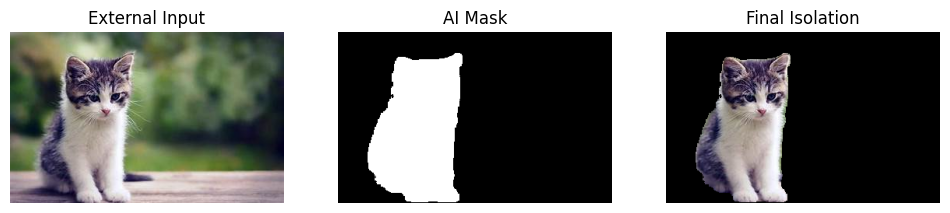

In [20]:
predict_external_image("/kaggle/input/test-data-set/cat.jpg", model)

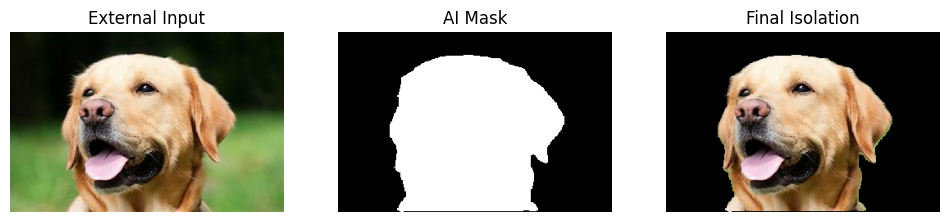

In [21]:
predict_external_image("/kaggle/input/test-data-set/dog.jpg", model)

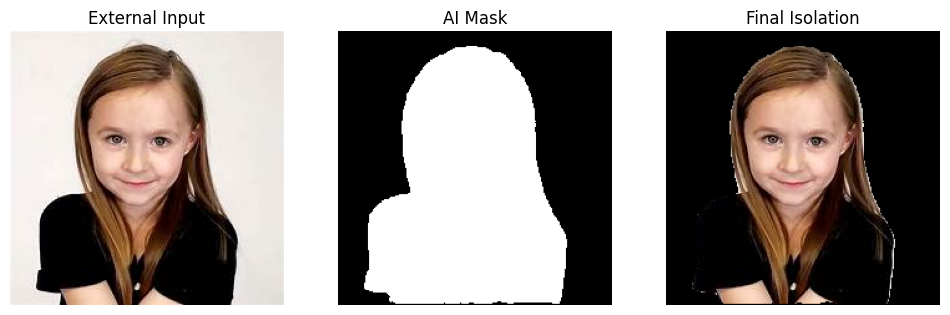

In [22]:
predict_external_image("/kaggle/input/test-data-set/girl.jpg", model)

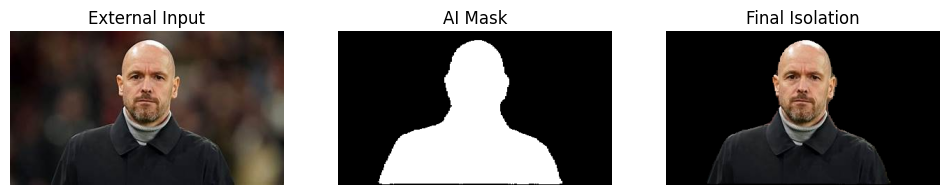

In [23]:
predict_external_image("/kaggle/input/test-data-set/man.jpg", model)

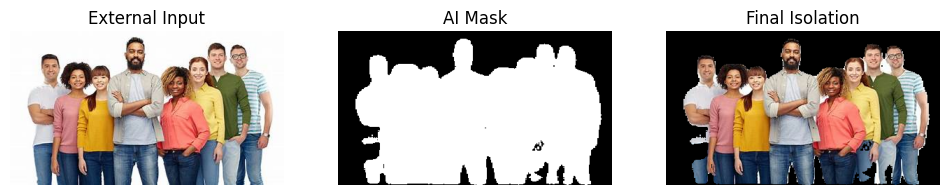

In [24]:
predict_external_image("/kaggle/input/test-data-set/people.jpg", model)

In [27]:
!ls -lh /kaggle/working


total 94M
-rw-r--r-- 1 root root 94M Nov 28 14:34 best_model_v2.pth
